In [312]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
import matplotlib
import pandas as pd
from tqdm import tqdm
from nltk import word_tokenize
from torchvision.ops import nms
from torchvision.ops.boxes import masks_to_boxes
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import mean_absolute_error

as of 9th dec 2025, install transformers from source

```
git clone https://github.com/huggingface/transformers.git
cd transformers
pip install '.[torch]'
```

In [2]:
root_path = "/home/stefan/ioai-prep/kits/rooms"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam3_path = "/mnt/projects/models/sam3"
model = Sam3Model.from_pretrained(sam3_path).to(device).half()
processor = Sam3Processor.from_pretrained(sam3_path)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


# Explore SAM3

In [3]:
def overlay_masks(image, masks, alpha_fac=0.85):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(n_masks)]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * alpha_fac))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image

In [4]:
# Load image
image_path = f"{root_path}/images/image888.png"
image = Image.open(image_path).convert("RGB")

# Segment using text prompt
inputs = processor(images=image, text="chair", return_tensors="pt").to(device)

with torch.no_grad():
    inputs = {k: v.half() if v.dtype == torch.float32 else v 
              for k, v in inputs.items()}
    outputs = model(**inputs)

# Post-process results
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist(),
)[0]

print(f"Found {len(results['masks'])} objects")

Found 6 objects


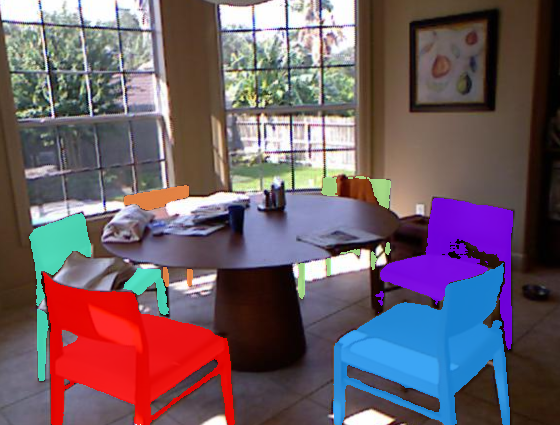

In [5]:
overlay_masks(image, results["masks"])

# Data

In [6]:
lemmatizer = WordNetLemmatizer()

def extract_obj(question):
    tok = word_tokenize(question)
    tok = tok[2:] # skip "how many"

    obj = []
    for t in tok:
        if t != "are" and t != "can" and t != "have" and t != "does":
            obj.append(lemmatizer.lemmatize(t))
        else:
            break

    return " ".join(obj)


def load_df(is_train: bool = False):
    df = pd.read_csv(f"{root_path}/{'train' if is_train else 'test'}.csv")

    df["obj"] = df["question"].apply(extract_obj)
    return df

In [174]:
test_df = load_df()
train_df = load_df(is_train=True)

test_df.head()

,sample_id,question,image_id,obj
0,TEST0000,how many drawers are there,image1362,drawer
1,TEST0001,how many televisions are there,image169,television
2,TEST0002,how many flags are visible,image1326,flag
3,TEST0003,how many drawers are there,image898,drawer
4,TEST0004,how many chairs are there,image632,chair


In [42]:
test_df["obj"].head(20)

0                         drawer
1                     television
2                           flag
3                         drawer
4                          chair
5                 stack of paper
6                          photo
7                           knob
8                     blue chair
9                           door
10                          door
11                 white monitor
12                   drawer knob
13                         chair
14                          sofa
15                      cupboard
16                          lamp
17    is the roll of paper towel
18                         chair
19                       toy box
Name: obj, dtype: object

prompt lengths


<Axes: >

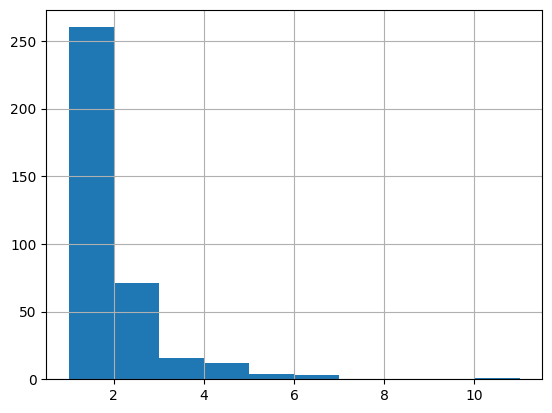

In [9]:
print("prompt lengths")
test_df["obj"].apply(lambda words: len(word_tokenize(words))).hist()
# mean = 1.490463
# std = 1.03

# Object detection

In [ ]:
def get_obj_cnt(image_path, prompt, conf_threshold=0.5, mask_threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        inputs = {
            k: v.half() if v.dtype == torch.float32 else v for k, v in inputs.items()
        }
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=conf_threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs.get("original_sizes").tolist(),
    )[0]

    masks = results["masks"]
    return len(masks)

In [309]:
train_answers = []

for row_idx in tqdm(range(len(train_df))):
    row = train_df.iloc[row_idx]
    img_path = f"{root_path}/images/{row['image_id']}.png"

    ans = get_obj_cnt(img_path, row["obj"], conf_threshold=0.7)
    train_answers.append(ans)

100%|██████████| 1326/1326 [04:31<00:00,  4.88it/s]


In [313]:
mean_absolute_error(train_df["answer"], train_answers)

2.9683257918552037

# Submission

In [ ]:
submission = test_df[["sample_id"]]
answers = []

In [ ]:
for row_idx in tqdm(range(len(test_df))):
    row = test_df.iloc[row_idx]
    img_path = f"{root_path}/images/{row['image_id']}.png"

    ans = get_obj_cnt(img_path, row["obj"], conf_threshold=0.7)
    answers.append(ans)

100%|██████████| 367/367 [01:17<00:00,  4.72it/s]


In [ ]:
nonnull = len(list(filter(lambda x: x != 0, answers))) / len(answers) * 100

f"{nonnull:.1f}% of images have answers"

'81.2% of images have answers'

In [314]:
submission.loc[:, "answer"] = answers

zero_mask = submission["answer"] == 0
# submission.loc[zero_mask, "answer"] = 2

submission.head()

,sample_id,answer
0,TEST0000,4
1,TEST0001,1
2,TEST0002,1
3,TEST0003,5
4,TEST0004,2


In [315]:
submission.describe()

,answer
count,367.000000
mean,3.051771
std,3.152766
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,24.000000


In [316]:
submission.to_csv(f"{root_path}/submission.csv")